 <a href="https://colab.research.google.com/github/geoUFSC/python/blob/main/idw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Interpolação pelo método do inverso da distância (IDW)

Este notebook resolve o projeto de interpolação usando o **inverso da distância (IDW)**.

In [108]:
# Pacotes necessários
import numpy as np
import matplotlib.pyplot as plt

In [109]:
# ==========================================================
# FUNÇÕES
# ==========================================================

# Função para calcular a distância euclidiana
def distancia_euclidiana(xi, yi, x0, y0):
    """Calcula a distância euclidiana entre dois pontos no plano."""
    return np.sqrt((xi - x0)**2 + (yi - y0)**2)

# Função para interpolação IDW (Inverse Distance Weighting) com tratamento de caso especial
def idw(x, y, z, x0, y0, p=2):
    """
    Calcula o valor interpolado pelo método do inverso da distância (IDW).

    Parâmetros
    ----------
    x, y : arrays
        Coordenadas dos pontos amostrais.
    z : array
        Valores conhecidos nos pontos amostrais.
    x0, y0 : float
        Coordenadas do ponto onde se deseja interpolar.
    p : float
        Expoente de ponderação.

    Retorna
    -------
    z0 : float
        Valor interpolado no ponto (x0, y0).
    distancias : array
        Distâncias entre o ponto interpolado e os pontos amostrais.
    pesos : array
        Pesos associados a cada ponto amostral.
    """
    distancias = distancia_euclidiana(x, y, x0, y0)

    # Caso especial: se o ponto interpolado coincide com um ponto amostral
    if np.any(distancias == 0):
        indice = np.where(distancias == 0)[0][0]
        return z[indice], distancias, None

    pesos = 1 / (distancias ** p)
    z0 = np.sum(pesos * z) / np.sum(pesos)

    return z0, distancias, pesos


In [110]:
# ==========================================================
# TESTES
# ==========================================================
p = 1  # Expoente de ponderação para os testes

# testando a função com um exemplo simples
x = np.array([0, 1])
y = np.array([0, 0])
z = np.array([10, 20])
x0, y0 = 0.5, 0
z0, distancias, pesos = idw(x, y, z, x0, y0, p)
print(f"Valor interpolado no ponto ({x0}, {y0}): {z0}")
if z0 == 15:
    print("Teste 1 passou!")
else:
    print("Teste 1 falhou.")

#testando a função com um exemplo onde o ponto interpolado coincide com um ponto amostral
x0, y0 = 1, 0
z0, distancias, pesos = idw(x, y, z, x0, y0, p)
print(f"Valor interpolado no ponto ({x0}, {y0}): {z0}")

if z0 == 20:
    print("Teste 2 de caso especial passou!")
else:
    print("Teste 2 de caso especial falhou.")



Valor interpolado no ponto (0.5, 0): 15.0
Teste 1 passou!
Valor interpolado no ponto (1, 0): 20
Teste 2 de caso especial passou!


In [111]:
# ==========================================================
# DADOS DO PROBLEMA
# ==========================================================

"Temos 5 pontos amostrais com coordenadas (x, y) e valores observados (z). "
"Deseja-se estimar o valor no ponto (x0, y0) = (3, 0.5)"

# Coordenadas dos pontos amostrais
x = np.array([0, 2, 4, 6, 8], dtype=float)
y = np.array([0, 1, 0, 1, 0], dtype=float)
z = np.array([10, 12, 15, 14, 13], dtype=float)

# Ponto onde será feita a interpolação
x0 = 3.0
y0 = 0.5

print("Pontos amostrais:")
for i in range(len(x)):
    print(f"P{i+1}: x = {x[i]:.1f}, y = {y[i]:.1f}, z = {z[i]:.1f}")

print(f"\nPonto de interpolação: ({x0}, {y0})")

Pontos amostrais:
P1: x = 0.0, y = 0.0, z = 10.0
P2: x = 2.0, y = 1.0, z = 12.0
P3: x = 4.0, y = 0.0, z = 15.0
P4: x = 6.0, y = 1.0, z = 14.0
P5: x = 8.0, y = 0.0, z = 13.0

Ponto de interpolação: (3.0, 0.5)


In [112]:
#Cálculo das distâncias e interpolação para diferentes valores de p

valores_p = [1, 2, 3]
resultados = {}

for p in valores_p:
    z0, distancias, pesos = idw(x, y, z, x0, y0, p=p)
    resultados[p] = z0

    print(f"Resultados para p = {p}")
    print("-" * 40)
    for i in range(len(x)):
        if pesos is not None:
            print(
                f"P{i+1}: distância para (x0,y0) = {distancias[i]:.4f} | "
                f"peso = {pesos[i]:.4f} | z = {z[i]:.1f}"
            )
        else:
            print(f"P{i+1}: distância para (x0,y0) = {distancias[i]:.4f} | z = {z[i]:.1f}")

    print(f"Valor interpolado: z0 = {z0:.4f}\n")


Resultados para p = 1
----------------------------------------
P1: distância para (x0,y0) = 3.0414 | peso = 0.3288 | z = 10.0
P2: distância para (x0,y0) = 1.1180 | peso = 0.8944 | z = 12.0
P3: distância para (x0,y0) = 1.1180 | peso = 0.8944 | z = 15.0
P4: distância para (x0,y0) = 3.0414 | peso = 0.3288 | z = 14.0
P5: distância para (x0,y0) = 5.0249 | peso = 0.1990 | z = 13.0
Valor interpolado: z0 = 13.0895

Resultados para p = 2
----------------------------------------
P1: distância para (x0,y0) = 3.0414 | peso = 0.1081 | z = 10.0
P2: distância para (x0,y0) = 1.1180 | peso = 0.8000 | z = 12.0
P3: distância para (x0,y0) = 1.1180 | peso = 0.8000 | z = 15.0
P4: distância para (x0,y0) = 3.0414 | peso = 0.1081 | z = 14.0
P5: distância para (x0,y0) = 5.0249 | peso = 0.0396 | z = 13.0
Valor interpolado: z0 = 13.3146

Resultados para p = 3
----------------------------------------
P1: distância para (x0,y0) = 3.0414 | peso = 0.0355 | z = 10.0
P2: distância para (x0,y0) = 1.1180 | peso = 0.7155 

## Resultados gráficos

13.314569154458413


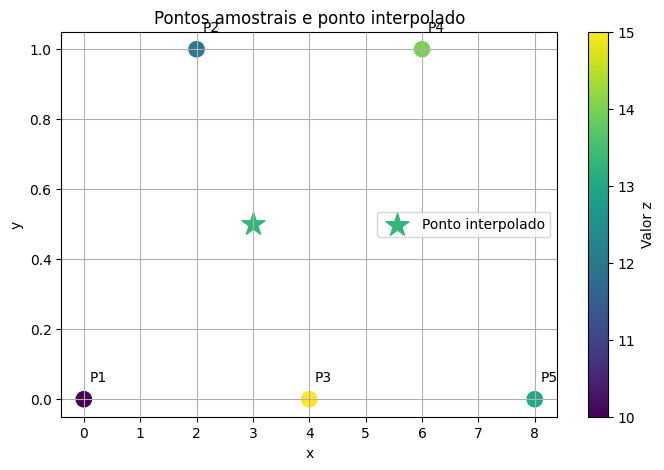

In [113]:
# ==========================================================
# GRÁFICO 1 - Distribuição espacial dos pontos amostrais e do ponto interpolado
# ==========================================================

# Coordenadas dos pontos amostrais
x = np.array([0, 2, 4, 6, 8], dtype=float)
y = np.array([0, 1, 0, 1, 0], dtype=float)
z = np.array([10, 12, 15, 14, 13], dtype=float)
# Ponto onde será feita a interpolação
x0 = 3.0
y0 = 0.5
p = 2

z0, _, _ = idw(x, y, z, x0, y0, p)
print(z0)

plt.figure(figsize=(8, 5))
sc = plt.scatter(x, y, c=z, s=120, cmap='viridis', vmin=z.min(), vmax=z.max())
plt.scatter(x0, y0, c=[z0], marker='*', s=300, label='Ponto interpolado',
            cmap='viridis', vmin=z.min(), vmax=z.max())
for i in range(len(x)):
    plt.text(x[i] + 0.1, y[i] + 0.05, f"P{i+1}", fontsize=10)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Pontos amostrais e ponto interpolado")
plt.legend()
plt.colorbar(sc, label="Valor z")
plt.grid(True)
plt.show()

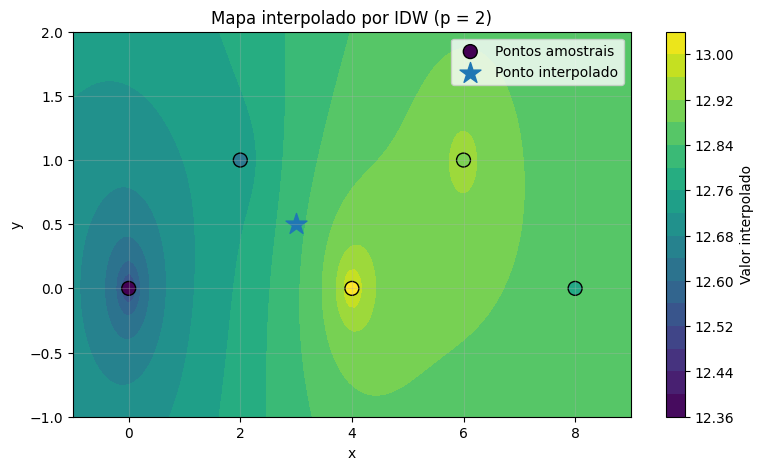

In [114]:
# ==========================================================
# GRÁFICO 2 - Mapa interpolado
# ==========================================================
# Agora será criada uma malha de pontos em toda a área de interesse. Para cada ponto da malha, o método IDW será aplicado, gerando um campo interpolado.

p = 0.1  # Expoente de ponderação para o IDW

# Definição da malha
x_grid = np.linspace(min(x) - 1, max(x) + 1, 120)
y_grid = np.linspace(min(y) - 1, max(y) + 1, 120)
X, Y = np.meshgrid(x_grid, y_grid)

# Cálculo do mapa interpolado
Z = np.zeros_like(X, dtype=float)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j], _, _ = idw(x, y, z, X[i, j], Y[i, j], p)

plt.figure(figsize=(9, 5))
cont = plt.contourf(X, Y, Z, levels=20)
plt.scatter(x, y, c=z, edgecolors='black', s=100, label='Pontos amostrais')
plt.scatter(x0, y0, marker='*', s=250, label='Ponto interpolado')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Mapa interpolado por IDW (p = 2)")
plt.colorbar(cont, label="Valor interpolado")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

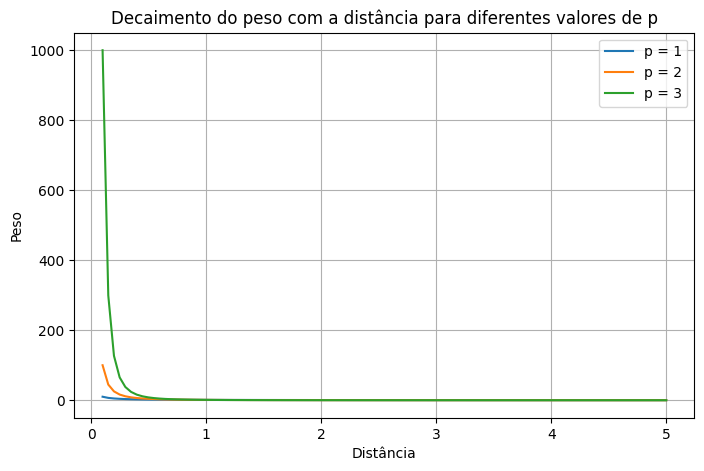

In [115]:
# ==========================================================
# GRÁFICO 3 - Decaimento do peso com o aumento da distancias para p=1, p=2 e p=3
# ==========================================================

distancias = np.linspace(0.1, 5, 100)  # Evitar divisão por zero
pesos_p1 = 1 / (distancias ** 1)
pesos_p2 = 1 / (distancias ** 2)
pesos_p3 = 1 / (distancias ** 3)
plt.figure(figsize=(8, 5))
plt.plot(distancias, pesos_p1, label='p = 1')
plt.plot(distancias, pesos_p2, label='p = 2')
plt.plot(distancias, pesos_p3, label='p = 3')
plt.xlabel("Distância")
plt.ylabel("Peso")
plt.title("Decaimento do peso com a distância para diferentes valores de p")
plt.legend()
plt.grid(True)
plt.show()

## Respostas às perguntas da lista

### 1. O que acontece com o resultado da interpolação quando o valor de `p` aumenta?
Quando `p` aumenta, os pontos mais próximos passam a ter **peso ainda maior** na interpolação, enquanto os pontos mais distantes perdem influência. Assim, o valor interpolado tende a ficar mais próximo dos valores observados nos pontos vizinhos imediatos.

### 2. Por que os pontos mais próximos têm maior influência no método IDW?
Porque o método atribui pesos proporcionais a `1/d^p`. Isso significa que, quanto menor a distância `d`, maior será o peso associado ao ponto.

### 3. Cite um exemplo de aplicação desse método em Geociências.
O IDW pode ser usado, por exemplo, para:
- estimar níveis d’água subterrânea;
- interpolar altitudes do terreno;
- mapear concentração de contaminantes no solo;
- estimar teores de um elemento químico a partir de amostras pontuais.

### 4. Quais são as limitações do método IDW?
Entre as principais limitações:
- o método depende fortemente da distribuição espacial das amostras;
- não considera tendências regionais nem anisotropia de forma explícita;
- pode gerar superfícies artificiais se os dados forem escassos;
- o resultado depende da escolha do expoente `p`.